# STEERER + MovingDroneCrowd++ — validation and test Colab runner

This notebook evaluates the repository's **pretrained image-level STEERER counter** on every frame in the selected MDC++ validation or test split. It does not train the model or instantiate SDNet/GD3A video counting.

The durable output is a small per-image `predictions.csv` plus `summary.json`. Density maps are optional and disabled by default because they are not needed for MAE/RMSE or later count-range analysis. Progress is copied to Drive every few images, and an interrupted full test can resume without repeating completed frames.

Recommended order:

1. Select a GPU runtime in Colab.
2. Select `TEST_SPLIT = "val.txt"` or `"test.txt"` and use a separate `RUN_NAME` for each experiment. Run all cells once with `ACTION = "smoke"`.
3. Check that three predictions and a summary were saved.
4. Set `ACTION = "evaluate"`, then rerun the control panel, preflight, action, and result-viewer cells. Only the held-out test split requires `CONFIRM_FULL_TEST = True`. Validation outputs are saved under `val/`; test outputs remain under `test/`.

The official checkpoint is downloaded automatically and cached in `MyDrive/MDC_STEERER/checkpoints`. The existing dataset archive used by the other notebooks is reused by default, so no duplicate dataset upload is required.


In [9]:
# @title 0. Control panel — normally this is the only cell you edit
from pathlib import Path

# ---------- CURRENT ACTION ----------
ACTION = "evaluate"  # @param ["inspect", "smoke", "evaluate"]

# ---------- REPOSITORY AND DATA ----------
REPO_URL = "https://github.com/gabrielxmit10/MovingDroneCrowd.git"  # @param {type:"string"}
REPO_REF = "main"  # @param {type:"string"}
REPO_DIR = Path("/content/MDC_STEERER")
DRIVE_PROJECT = Path("/content/drive/MyDrive/MDC_STEERER")

DATA_SOURCE = "archive"  # @param ["archive", "drive_folder", "already_staged"]
DATASET_ARCHIVE = Path("/content/drive/MyDrive/P2PNet_MDC/data/MovingDroneCrowd++.tar")  # @param {type:"string"}
DRIVE_DATASET_FOLDER = Path("/content/drive/MyDrive/P2PNet_MDC/data/MovingDroneCrowd++")  # @param {type:"string"}
DATASET_ROOT = Path("/content/data/MovingDroneCrowd++")
TEST_SPLIT = "val.txt"  # @param ["val.txt", "test.txt"] Select the extended MDC++ split

# ---------- OFFICIAL STEERER CHECKPOINT ----------
CHECKPOINT_SOURCE = "download"  # @param ["download", "drive"]
CHECKPOINT_URL = "https://huggingface.co/fyw1999/MovingDroneCrowd-Weights/resolve/main/GD3A_pre_trained_global_counter_STEERER_MDC%2B%2B_ep_201_mae_13.5_mse_19.1.pth"
DRIVE_CHECKPOINT = DRIVE_PROJECT / "checkpoints/GD3A_pre_trained_global_counter_STEERER_MDC++_ep_201_mae_13.5_mse_19.1.pth"
LOCAL_CHECKPOINT = Path("/content/steerer_checkpoints") / DRIVE_CHECKPOINT.name

# ---------- RUN AND EVALUATION ----------
RUN_NAME = "steerer_mdc_val_reference"  # @param {type:"string"}
RUN_DIR = DRIVE_PROJECT / "runs" / RUN_NAME
DEVICE = "cuda:0"  # @param ["cuda:0", "cpu"]
SMOKE_SAMPLES = 3  # @param {type:"integer"}
EVAL_MAX_SAMPLES = 0  # @param {type:"integer"} 0 means the complete selected split
FRAME_STRIDE = 1  # @param {type:"integer"} keep 1 for the final result
CONFIRM_FULL_TEST = True  # @param {type:"boolean"}
RESUME_EXISTING = True  # @param {type:"boolean"}
SYNC_EVERY = 10  # @param {type:"integer"}
SEED = 3035  # @param {type:"integer"}

# These reproduce the repository's MDC++ test preprocessing. Changing them changes the experiment.
MAX_LONG_SIDE = 1920  # @param {type:"integer"}
MAX_SHORT_SIDE = 1080  # @param {type:"integer"}
USE_AMP = False  # @param {type:"boolean"} FP32 is the reference setting

# Optional large artifacts. Counts/errors are always saved; density maps are not needed for metrics.
SAVE_DENSITY_MAPS = False  # @param {type:"boolean"}
DENSITY_MAP_LIMIT = 20  # @param {type:"integer"} 0 means every selected image

# Editable only for the post-run analysis table; it does not change model evaluation.
COUNT_BINS = [0, 50, 100, 200, 500, float("inf")]


## 1. Mount Drive and inspect the runtime

Drive folders are created automatically. The only interactive step is Google's normal Drive authorization prompt.


In [3]:
from google.colab import drive
import datetime, json, os, platform, re, shlex, shutil, subprocess, sys, tarfile, time

drive.mount("/content/drive")
DRIVE_PROJECT.mkdir(parents=True, exist_ok=True)
RUN_DIR.mkdir(parents=True, exist_ok=True)
DRIVE_CHECKPOINT.parent.mkdir(parents=True, exist_ok=True)
print("Python:", sys.version.split()[0])
subprocess.run(["nvidia-smi"], check=False)
usage = shutil.disk_usage("/content")
print(f"/content free: {usage.free / 2**30:.1f} GiB")
if DEVICE.startswith("cuda") and shutil.which("nvidia-smi") is None:
    raise RuntimeError("A GPU was requested. In Colab choose Runtime > Change runtime type > GPU.")


Mounted at /content/drive
Python: 3.13.15
/content free: 193.2 GiB


## 2. Clone the repository and install the minimal STEERER dependencies

The notebook checks that the evaluation backend is present. If this check fails, push this notebook, `evaluate_steerer_mdc.py`, `requirements-colab-steerer.txt`, and `model/density_estimator/STEERER/heads/counting_head.py` to `REPO_URL`/`REPO_REF`, then rerun the cell.


In [4]:
def clean_repo_url(value):
    value = str(value).strip()
    markdown_link = re.fullmatch(r"\[[^\]]+\]\((https?://[^)]+)\)", value)
    return (markdown_link.group(1) if markdown_link else value).rstrip("\\")

REPO_URL = clean_repo_url(REPO_URL)
if not REPO_DIR.exists():
    subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)
elif not (REPO_DIR / ".git").is_dir():
    raise RuntimeError(f"{REPO_DIR} exists but is not a Git checkout")
else:
    print("Reusing runtime checkout:", REPO_DIR)
remote = subprocess.check_output(["git", "remote", "get-url", "origin"], cwd=REPO_DIR, text=True).strip()
if remote.rstrip("/").removesuffix(".git") != REPO_URL.rstrip("/").removesuffix(".git"):
    raise RuntimeError(f"Existing checkout uses a different origin: {remote}")
subprocess.run(["git", "fetch", "origin", REPO_REF], cwd=REPO_DIR, check=True)
subprocess.run(["git", "checkout", REPO_REF], cwd=REPO_DIR, check=True)
if REPO_REF == "main":
    subprocess.run(["git", "merge", "--ff-only", "origin/main"], cwd=REPO_DIR, check=True)
required_files = ["evaluate_steerer_mdc.py", "requirements-colab-steerer.txt", "model/density_estimator/STEERER/configs/MDC.py", "model/density_estimator/STEERER/heads/counting_head.py"]
missing_backend = [name for name in required_files if not (REPO_DIR / name).is_file()]
if missing_backend:
    raise RuntimeError(f"The GitHub checkout is missing {missing_backend}. Push the local changes, then rerun.")
head_source = (REPO_DIR / "model/density_estimator/STEERER/heads/counting_head.py").read_text(encoding="utf-8")
if "from .base_head import BaseHead" in head_source:
    raise RuntimeError("The GitHub checkout still has the old MMCV import. Push counting_head.py and rerun this cell.")
# Show the full pip error if installation fails; the Colab Python version may change.
subprocess.run([sys.executable, "-m", "pip", "install", "-r", "requirements-colab-steerer.txt"], cwd=REPO_DIR, check=True)
os.chdir(REPO_DIR)

def run_command(command):
    command = [str(value) for value in command]
    rendered = shlex.join(command)
    print("$", rendered)
    with (DRIVE_PROJECT / "action_commands.log").open("a", encoding="utf-8") as handle:
        handle.write(f"{datetime.datetime.now().isoformat()}\t{rendered}\n")
    log_dir = DRIVE_PROJECT / "command_logs"
    log_dir.mkdir(parents=True, exist_ok=True)
    stamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S_%f")
    log_path = log_dir / f"{stamp}_{Path(command[1]).stem}.log"
    environment = dict(os.environ, PYTHONUNBUFFERED="1")
    with log_path.open("w", encoding="utf-8") as log:
        log.write("$ " + rendered + "\n")
        with subprocess.Popen(command, cwd=REPO_DIR, stdout=subprocess.PIPE,
                              stderr=subprocess.STDOUT, text=True, bufsize=1,
                              env=environment) as process:
            for line in process.stdout:
                print(line, end="", flush=True)
                log.write(line)
                log.flush()
            return_code = process.wait()
    if return_code:
        raise RuntimeError(f"Command exited with code {return_code}. Full output: {log_path}")
    print("Command log:", log_path)

import torch
commit = subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=REPO_DIR, text=True).strip()
print("Commit:", commit)
print("PyTorch:", torch.__version__, "CUDA:", torch.cuda.is_available())


Commit: ab8d3b0cd58940e0b872b7104120602e5b263af5
PyTorch: 2.11.0+cu130 CUDA: True


## 3. Stage MDC++ on fast runtime storage

The default points at the same archive used by the P2PNet and MPCount notebooks. Copying and extracting it can take several minutes, but inference from `/content` is much faster and more reliable than reading thousands of files directly from mounted Drive.


In [5]:
DATASET_ROOT.parent.mkdir(parents=True, exist_ok=True)
if DATASET_ROOT.exists():
    print("Dataset already staged:", DATASET_ROOT)
elif DATA_SOURCE == "archive":
    if not DATASET_ARCHIVE.is_file():
        raise FileNotFoundError(f"Dataset archive not found: {DATASET_ARCHIVE}. Update DATASET_ARCHIVE in the control panel.")
    archive_size = DATASET_ARCHIVE.stat().st_size
    free = shutil.disk_usage("/content").free
    if free < archive_size * 2.2:
        raise RuntimeError(f"Not enough /content disk: free={free/2**30:.1f} GiB, archive={archive_size/2**30:.1f} GiB")
    local_archive = Path("/content") / DATASET_ARCHIVE.name
    extract_root = Path("/content") / f"mdc_extract_{int(time.time())}"
    extract_root.mkdir(parents=True, exist_ok=False)
    print("Copying the archive from Drive to runtime storage...")
    shutil.copy2(DATASET_ARCHIVE, local_archive)
    print("Extracting MDC++...")
    try:
        with tarfile.open(local_archive) as archive:
            try:
                archive.extractall(extract_root, filter="data")
            except TypeError:
                archive.extractall(extract_root)
        candidates = [extract_root / "MovingDroneCrowd++", extract_root]
        source_root = next((candidate for candidate in candidates if (candidate / "frames").is_dir() and (candidate / "annotations").is_dir()), None)
        if source_root is None:
            raise RuntimeError("Archive did not contain the expected MovingDroneCrowd++ layout")
        shutil.move(str(source_root), str(DATASET_ROOT))
    finally:
        local_archive.unlink(missing_ok=True)
        if extract_root.exists():
            shutil.rmtree(extract_root)
elif DATA_SOURCE == "drive_folder":
    if not DRIVE_DATASET_FOLDER.is_dir():
        raise FileNotFoundError(DRIVE_DATASET_FOLDER)
    print("Copying the dataset folder from Drive; an archive is normally faster...")
    shutil.copytree(DRIVE_DATASET_FOLDER, DATASET_ROOT)
elif DATA_SOURCE != "already_staged":
    raise ValueError(f"Unknown DATA_SOURCE={DATA_SOURCE!r}")
required_data = ["frames", "annotations", TEST_SPLIT]
missing_data = [item for item in required_data if not (DATASET_ROOT / item).exists()]
if missing_data:
    raise RuntimeError(f"Staged dataset is incomplete; missing {missing_data} under {DATASET_ROOT}")
print("Dataset ready:", DATASET_ROOT)


Copying the archive from Drive to runtime storage...
Extracting MDC++...
Dataset ready: /content/data/MovingDroneCrowd++


## 4. Download/cache the official MDC++ STEERER checkpoint

With `CHECKPOINT_SOURCE = "download"`, no manual upload is needed. The public checkpoint is downloaded once to Drive and reused on future sessions. If automatic download is unavailable, upload that exact `.pth` file to `DRIVE_CHECKPOINT` and select `CHECKPOINT_SOURCE = "drive"`.


In [6]:
DRIVE_CHECKPOINT.parent.mkdir(parents=True, exist_ok=True)
if CHECKPOINT_SOURCE == "download" and not DRIVE_CHECKPOINT.is_file():
    temporary_download = Path("/content") / (DRIVE_CHECKPOINT.name + ".download")
    print("Downloading official STEERER MDC++ checkpoint...")
    subprocess.run(["wget", "--progress=bar:force:noscroll", "-O", str(temporary_download), CHECKPOINT_URL], check=True)
    if temporary_download.stat().st_size < 1_000_000:
        raise RuntimeError("Downloaded checkpoint is unexpectedly small")
    shutil.copy2(temporary_download, DRIVE_CHECKPOINT)
    temporary_download.unlink()
elif CHECKPOINT_SOURCE not in {"download", "drive"}:
    raise ValueError(f"Unknown CHECKPOINT_SOURCE={CHECKPOINT_SOURCE!r}")
if not DRIVE_CHECKPOINT.is_file():
    raise FileNotFoundError(f"Checkpoint not found: {DRIVE_CHECKPOINT}")
LOCAL_CHECKPOINT.parent.mkdir(parents=True, exist_ok=True)
if not LOCAL_CHECKPOINT.is_file() or LOCAL_CHECKPOINT.stat().st_size != DRIVE_CHECKPOINT.stat().st_size:
    print("Copying checkpoint to runtime storage...")
    shutil.copy2(DRIVE_CHECKPOINT, LOCAL_CHECKPOINT)
print(f"Checkpoint ready: {LOCAL_CHECKPOINT} ({LOCAL_CHECKPOINT.stat().st_size / 2**20:.1f} MiB)")


Copying checkpoint to runtime storage...
Checkpoint ready: /content/steerer_checkpoints/GD3A_pre_trained_global_counter_STEERER_MDC++_ep_201_mae_13.5_mse_19.1.pth (247.7 MiB)


## 5. Preflight the complete selected split

This parses the split and every relevant annotation file but does not load the model or run inference. With stride 1, `val.txt` contains 724 images across 15 clips and `test.txt` contains 2,462 images across 41 clips.


In [7]:
from IPython.display import display
import pandas as pd

if ACTION not in {"inspect", "smoke", "evaluate"}:
    raise ValueError(f"Unknown ACTION={ACTION!r}")
if FRAME_STRIDE < 1 or SMOKE_SAMPLES < 1 or EVAL_MAX_SAMPLES < 0:
    raise ValueError("FRAME_STRIDE and SMOKE_SAMPLES must be positive; EVAL_MAX_SAMPLES cannot be negative")
PREFLIGHT_DIR = RUN_DIR / "preflight"
preflight_command = [
    sys.executable, "evaluate_steerer_mdc.py",
    "--data-root", DATASET_ROOT,
    "--split-file", TEST_SPLIT,
    "--output-dir", PREFLIGHT_DIR,
    "--frame-stride", FRAME_STRIDE,
    "--max-samples", 0,
    "--inspect-only",
]
run_command(preflight_command)
inspection = json.loads((PREFLIGHT_DIR / "dataset_inspection.json").read_text(encoding="utf-8"))
display(pd.DataFrame(inspection.items(), columns=["Check", "Value"]))
expected_samples = {"val.txt": 724, "test.txt": 2462}.get(TEST_SPLIT)
if FRAME_STRIDE == 1 and expected_samples is not None and inspection["selected_samples"] != expected_samples:
    raise RuntimeError(f"Expected {expected_samples:,} images for {TEST_SPLIT}, got {inspection['selected_samples']:,}. Verify the dataset version before evaluation.")
if ACTION == "evaluate" and Path(TEST_SPLIT).stem.lower().endswith("test") and not CONFIRM_FULL_TEST:
    print("BLOCKED UNTIL CONFIRMED: set CONFIRM_FULL_TEST=True before the full test action.")
elif ACTION == "inspect":
    print("Inspection complete; no model inference will run.")
else:
    print(f"Ready for ACTION={ACTION!r}.")


$ /usr/bin/python3 evaluate_steerer_mdc.py --data-root /content/data/MovingDroneCrowd++ --split-file val.txt --output-dir /content/drive/MyDrive/MDC_STEERER/runs/steerer_mdc_val_reference/preflight --frame-stride 1 --max-samples 0 --inspect-only
{
  "created_utc": "2026-10-01T23:42:56.168381+00:00",
  "data_root": "/content/data/MovingDroneCrowd++",
  "split_file": "val.txt",
  "frame_stride": 1,
  "max_samples": 0,
  "selected_samples": 724,
  "selected_clips": 15,
  "ground_truth_total": 64888,
  "ground_truth_min": 1,
  "ground_truth_max": 493,
  "ground_truth_mean": 89.62430939226519,
  "first_sample": "scene_4/1/1.jpg",
  "last_sample": "scene_41/1/46.jpg"
}
Command log: /content/drive/MyDrive/MDC_STEERER/command_logs/20261001_234255_563892_evaluate_steerer_mdc.log


,Check,Value
0,created_utc,2026-10-01T23:42:56.168381+00:00
1,data_root,/content/data/MovingDroneCrowd++
2,split_file,val.txt
3,frame_stride,1
4,max_samples,0
5,selected_samples,724
6,selected_clips,15
7,ground_truth_total,64888
8,ground_truth_min,1
9,ground_truth_max,493


Ready for ACTION='evaluate'.


## 6. Run the selected action

`smoke` evaluates the first few images of the selected split. `evaluate` uses the complete selected split when `EVAL_MAX_SAMPLES = 0` and `FRAME_STRIDE = 1`. Validation saves under `val/`, test under `test/`. The cell applies the CUDA memory-reset compatibility fix to older runtime checkouts automatically; it is safe to rerun. Existing compatible CSV rows are reused when resume is enabled.


In [8]:
if ACTION == "inspect":
    CURRENT_RESULT_DIR = PREFLIGHT_DIR
    print("ACTION='inspect': stopped after dataset preflight.")
else:
    if ACTION == "evaluate" and Path(TEST_SPLIT).stem.lower().endswith("test") and not CONFIRM_FULL_TEST:
        raise RuntimeError("Set CONFIRM_FULL_TEST=True in the control panel before evaluating the held-out test split.")
    action_name = "smoke" if ACTION == "smoke" else Path(TEST_SPLIT).stem
    max_samples = SMOKE_SAMPLES if ACTION == "smoke" else EVAL_MAX_SAMPLES
    CURRENT_RESULT_DIR = RUN_DIR / action_name
    local_work_dir = Path("/content/steerer_mdc_work") / RUN_NAME / action_name
    # Older GitHub/runtime copies still contain this optional CUDA stats call.
    # Each evaluation starts in a fresh process, so resetting it is unnecessary.
    evaluator_path = REPO_DIR / "evaluate_steerer_mdc.py"
    evaluator_source = evaluator_path.read_text(encoding="utf-8")
    compatible_source = evaluator_source.replace(
        "torch.cuda.reset_peak_memory_stats(device)",
        "pass  # CUDA memory-reset compatibility fix; fresh evaluation process",
    )
    compile(compatible_source, str(evaluator_path), "exec")
    if compatible_source != evaluator_source:
        evaluator_path.write_text(compatible_source, encoding="utf-8")
        print("Applied CUDA memory-reset compatibility fix to runtime evaluator.")
    CURRENT_RESULT_DIR.mkdir(parents=True, exist_ok=True)
    # Record the exact source used, including any runtime compatibility fix.
    shutil.copy2(evaluator_path, CURRENT_RESULT_DIR / "evaluator_used.py")
    print(f"Evaluating {TEST_SPLIT}; results: {CURRENT_RESULT_DIR}")
    command = [
        sys.executable, "evaluate_steerer_mdc.py",
        "--data-root", DATASET_ROOT,
        "--split-file", TEST_SPLIT,
        "--checkpoint", LOCAL_CHECKPOINT,
        "--output-dir", CURRENT_RESULT_DIR,
        "--work-dir", local_work_dir,
        "--device", DEVICE,
        "--frame-stride", FRAME_STRIDE,
        "--max-samples", max_samples,
        "--max-long", MAX_LONG_SIDE,
        "--max-short", MAX_SHORT_SIDE,
        "--seed", SEED,
        "--sync-every", SYNC_EVERY,
        "--density-map-limit", DENSITY_MAP_LIMIT,
        "--save-density-maps" if SAVE_DENSITY_MAPS else "--no-save-density-maps",
        "--use-amp" if USE_AMP else "--no-use-amp",
        "--resume" if RESUME_EXISTING else "--no-resume",
    ]
    run_command(command)
    summary = json.loads((CURRENT_RESULT_DIR / "summary.json").read_text(encoding="utf-8"))
    display(pd.DataFrame([{key: value for key, value in summary.items() if not isinstance(value, (dict, list))}]))
    latest_action = {
        "updated_utc": datetime.datetime.now(datetime.timezone.utc).isoformat(),
        "action": ACTION,
        "split_file": TEST_SPLIT,
        "output_dir": str(CURRENT_RESULT_DIR),
        "status": summary["status"],
    }
    (DRIVE_PROJECT / "latest_action.json").write_text(json.dumps(latest_action, indent=2), encoding="utf-8")


$ /usr/bin/python3 evaluate_steerer_mdc.py --data-root /content/data/MovingDroneCrowd++ --split-file val.txt --checkpoint /content/steerer_checkpoints/GD3A_pre_trained_global_counter_STEERER_MDC++_ep_201_mae_13.5_mse_19.1.pth --output-dir /content/drive/MyDrive/MDC_STEERER/runs/steerer_mdc_val_reference/test --work-dir /content/steerer_mdc_work/steerer_mdc_val_reference/test --device cuda:0 --frame-stride 1 --max-samples 0 --max-long 1920 --max-short 1080 --seed 3035 --sync-every 10 --density-map-limit 20 --no-save-density-maps --no-use-amp --resume
Traceback (most recent call last):
  File "/content/MDC_STEERER/evaluate_steerer_mdc.py", line 692, in <module>
    raise SystemExit(main())
                     ~~~~^^
  File "/content/MDC_STEERER/evaluate_steerer_mdc.py", line 687, in main
    evaluate(args)
    ~~~~~~~~^^^^^^
  File "/content/MDC_STEERER/evaluate_steerer_mdc.py", line 481, in evaluate
    torch.cuda.reset_peak_memory_stats(device)
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^

RuntimeError: Command exited with code 1. Full output: /content/drive/MyDrive/MDC_STEERER/command_logs/20261001_234256_529659_evaluate_steerer_mdc.log

## 7. Inspect saved per-image results

This reads only the saved Drive artifacts. It shows the worst individual errors and an editable ground-truth count-range analysis. Changing `COUNT_BINS` and rerunning this cell never reruns the model.


In [ ]:
if ACTION == "inspect":
    print(json.dumps(inspection, indent=2))
else:
    predictions_path = CURRENT_RESULT_DIR / "predictions.csv"
    summary_path = CURRENT_RESULT_DIR / "summary.json"
    if not predictions_path.is_file():
        raise FileNotFoundError(predictions_path)
    predictions = pd.read_csv(predictions_path)
    summary = json.loads(summary_path.read_text(encoding="utf-8"))
    print("Saved summary:")
    display(pd.DataFrame([{key: value for key, value in summary.items() if not isinstance(value, (dict, list))}]))
    print("Worst per-image absolute errors:")
    display(predictions.sort_values("absolute_error", ascending=False).head(20))

    if len(COUNT_BINS) < 2 or any(COUNT_BINS[i] >= COUNT_BINS[i + 1] for i in range(len(COUNT_BINS) - 1)):
        raise ValueError("COUNT_BINS must be strictly increasing")
    predictions["ground_truth_range"] = pd.cut(
        predictions["ground_truth_count"], bins=COUNT_BINS, right=False, include_lowest=True
    )
    range_metrics = predictions.groupby("ground_truth_range", observed=False).agg(
        images=("sample_id", "count"),
        ground_truth_mean=("ground_truth_count", "mean"),
        predicted_mean=("predicted_count", "mean"),
        mae=("absolute_error", "mean"),
        rmse=("squared_error", lambda values: float(values.mean() ** 0.5)),
    ).reset_index()
    print("Metrics by ground-truth crowd-count range:")
    display(range_metrics)
    print("Per-scene diagnostic (not the primary aggregate result):")
    scene_metrics = predictions.groupby("scene").agg(
        images=("sample_id", "count"),
        mae=("absolute_error", "mean"),
        rmse=("squared_error", lambda values: float(values.mean() ** 0.5)),
    ).sort_values("mae", ascending=False)
    display(scene_metrics)
    range_metrics.to_csv(CURRENT_RESULT_DIR / "metrics_by_count_range.csv", index=False)
    scene_metrics.to_csv(CURRENT_RESULT_DIR / "metrics_by_scene.csv")
    density_files = sorted((CURRENT_RESULT_DIR / "density_maps").glob("*.npz")) if (CURRENT_RESULT_DIR / "density_maps").is_dir() else []
    print(f"CSV size: {predictions_path.stat().st_size / 2**20:.3f} MiB; saved density maps: {len(density_files)}")
    print("Durable result directory:", CURRENT_RESULT_DIR)


Saved summary:


,status,created_utc,run_signature,expected_samples,completed_samples,missing_samples,unexpected_samples,mae,rmse,mean_signed_error,...,ground_truth_total,predicted_total,mean_inference_seconds,total_inference_seconds,script_wall_seconds_this_invocation,cuda_peak_reserved_mb_this_invocation,checkpoint_sha256,repo_commit,model_parameters,processed_this_invocation
0,complete,2026-10-01T04:44:13.768898+00:00,cc178776c8be6b4bffd300f6195c12c921bf3845e0c932...,2462,2462,0,0,16.939147,30.098379,-14.395271,...,221968.0,186526.843229,0.481518,1185.49802,1657.607079,12284.0,40d5e20447c0438fba6fd883e2275f64af12331fa349f7...,ab8d3b0cd58940e0b872b7104120602e5b263af5,64644615,2462


Worst per-image absolute errors:


,sample_id,image_relative_path,annotation_relative_path,scene,clip,frame_number,annotation_frame_index,ground_truth_count,predicted_count,signed_error,...,original_height,input_width,input_height,padded_width,padded_height,density_width,density_height,inference_seconds,density_relative_path,run_signature
1770,scene_30/3/25.jpg,frames/scene_30/3/25.jpg,annotations/scene_30/3.csv,scene_30,3,25,24,85,291.251770,206.251770,...,1440,1920,1080,1920,1088,1920,1088,0.509551,NaN,cc178776c8be6b4bffd300f6195c12c921bf3845e0c932...
1771,scene_30/3/26.jpg,frames/scene_30/3/26.jpg,annotations/scene_30/3.csv,scene_30,3,26,25,99,301.092896,202.092896,...,1440,1920,1080,1920,1088,1920,1088,0.507242,NaN,cc178776c8be6b4bffd300f6195c12c921bf3845e0c932...
1769,scene_30/3/24.jpg,frames/scene_30/3/24.jpg,annotations/scene_30/3.csv,scene_30,3,24,23,74,272.226227,198.226227,...,1440,1920,1080,1920,1088,1920,1088,0.501929,NaN,cc178776c8be6b4bffd300f6195c12c921bf3845e0c932...
2006,scene_33/1/101.jpg,frames/scene_33/1/101.jpg,annotations/scene_33/1.csv,scene_33,1,101,100,226,89.028625,-136.971375,...,2160,1920,1080,1920,1088,1920,1088,0.508380,NaN,cc178776c8be6b4bffd300f6195c12c921bf3845e0c932...
2003,scene_33/1/98.jpg,frames/scene_33/1/98.jpg,annotations/scene_33/1.csv,scene_33,1,98,97,234,97.263725,-136.736275,...,2160,1920,1080,1920,1088,1920,1088,0.507150,NaN,cc178776c8be6b4bffd300f6195c12c921bf3845e0c932...
2007,scene_33/1/102.jpg,frames/scene_33/1/102.jpg,annotations/scene_33/1.csv,scene_33,1,102,101,216,79.450592,-136.549408,...,2160,1920,1080,1920,1088,1920,1088,0.505812,NaN,cc178776c8be6b4bffd300f6195c12c921bf3845e0c932...
2000,scene_33/1/95.jpg,frames/scene_33/1/95.jpg,annotations/scene_33/1.csv,scene_33,1,95,94,241,106.275848,-134.724152,...,2160,1920,1080,1920,1088,1920,1088,0.507202,NaN,cc178776c8be6b4bffd300f6195c12c921bf3845e0c932...
2002,scene_33/1/97.jpg,frames/scene_33/1/97.jpg,annotations/scene_33/1.csv,scene_33,1,97,96,238,103.512199,-134.487801,...,2160,1920,1080,1920,1088,1920,1088,0.506512,NaN,cc178776c8be6b4bffd300f6195c12c921bf3845e0c932...
1998,scene_33/1/93.jpg,frames/scene_33/1/93.jpg,annotations/scene_33/1.csv,scene_33,1,93,92,240,107.033310,-132.966690,...,2160,1920,1080,1920,1088,1920,1088,0.506854,NaN,cc178776c8be6b4bffd300f6195c12c921bf3845e0c932...
1999,scene_33/1/94.jpg,frames/scene_33/1/94.jpg,annotations/scene_33/1.csv,scene_33,1,94,93,239,106.355576,-132.644424,...,2160,1920,1080,1920,1088,1920,1088,0.506510,NaN,cc178776c8be6b4bffd300f6195c12c921bf3845e0c932...


Metrics by ground-truth crowd-count range:


,ground_truth_range,images,ground_truth_mean,predicted_mean,mae,rmse
0,"[0.0, 50.0)",1131,28.867374,21.322911,8.577476,11.004735
1,"[50.0, 100.0)",425,72.997647,58.825379,17.652739,27.558064
2,"[100.0, 200.0)",680,138.602941,124.762671,16.640245,26.796301
3,"[200.0, 500.0)",209,265.114833,219.068606,54.235239,71.874785
4,"[500.0, inf)",17,508.000000,399.170031,108.829969,109.185036


Per-scene diagnostic (not the primary aggregate result):


,images,mae,rmse
scene,,,
scene_25,36,103.336810,103.756561
scene_33,135,80.912095,88.066455
scene_30,64,44.568593,65.593580
scene_4,83,25.379207,28.041047
scene_32,134,24.932311,31.522461
scene_20,61,20.378004,25.010718
scene_13,67,16.662771,19.447372
scene_17,249,15.997317,19.050203
scene_8,295,13.565357,15.745549


CSV size: 0.643 MiB; saved density maps: 0
Durable result directory: /content/drive/MyDrive/MDC_STEERER/runs/steerer_mdc_full_test/test


Images: 2462
MAE: 16.94
RMSE: 30.10
Bias: -14.40
Median absolute error: 8.90
90th-percentile absolute error: 42.08


,images,actual_mean,predicted_mean,mae,bias
count_range,,,,,
"[0.0, 50.0)",1131,28.87,21.32,8.58,-7.54
"[50.0, 100.0)",425,73.00,58.83,17.65,-14.17
"[100.0, 200.0)",680,138.60,124.76,16.64,-13.84
"[200.0, 500.0)",209,265.11,219.07,54.24,-46.05
"[500.0, inf)",17,508.00,399.17,108.83,-108.83


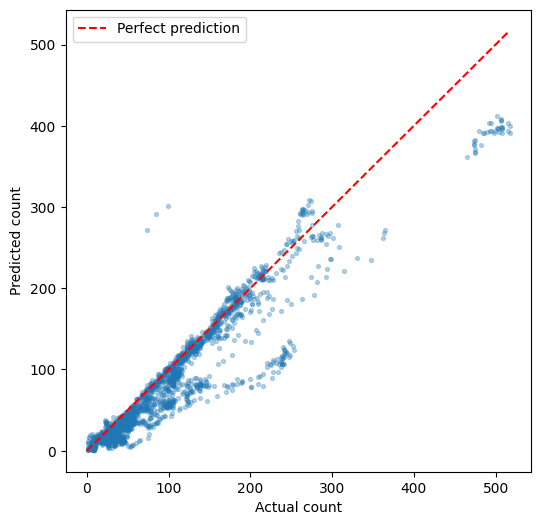

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if ACTION == "inspect":
    print("Inspection only; no predictions to plot.")
else:
    print("Reading selected run:", CURRENT_RESULT_DIR)
    df = pd.read_csv(CURRENT_RESULT_DIR / "predictions.csv")

    print(f"Images: {len(df)}")
    print(f"MAE: {df.absolute_error.mean():.2f}")
    print(f"RMSE: {np.sqrt(df.squared_error.mean()):.2f}")
    print(f"Bias: {df.signed_error.mean():+.2f}")
    print(f"Median absolute error: {df.absolute_error.median():.2f}")
    print(f"90th-percentile absolute error: {df.absolute_error.quantile(.90):.2f}")

    df["count_range"] = pd.cut(
        df.ground_truth_count,
        COUNT_BINS,
        right=False,
    )
    display(df.groupby("count_range", observed=True).agg(
        images=("sample_id", "count"),
        actual_mean=("ground_truth_count", "mean"),
        predicted_mean=("predicted_count", "mean"),
        mae=("absolute_error", "mean"),
        bias=("signed_error", "mean"),
    ).round(2))

    limit = max(df.ground_truth_count.max(), df.predicted_count.max())
    plt.figure(figsize=(6, 6))
    plt.scatter(df.ground_truth_count, df.predicted_count, s=8, alpha=.3)
    plt.plot([0, limit], [0, limit], "r--", label="Perfect prediction")
    plt.xlabel("Actual count")
    plt.ylabel("Predicted count")
    plt.legend()
    plt.show()

In [ ]:
if ACTION != "inspect":
    range_metrics.to_csv(CURRENT_RESULT_DIR / "metrics_by_count_range.csv", index=False)
    scene_metrics.to_csv(CURRENT_RESULT_DIR / "metrics_by_scene.csv")
    print("Saved to:", CURRENT_RESULT_DIR)

Saved to: /content/drive/MyDrive/MDC_STEERER/runs/steerer_mdc_full_test/test


## What you must do

- Push this notebook, the evaluation script, the requirements file, and `model/density_estimator/STEERER/heads/counting_head.py` to the configured GitHub repository before opening it in Colab.
- Confirm the default dataset archive path exists in your Drive; otherwise change `DATASET_ARCHIVE`.
- Approve the normal Drive mount prompt and use a GPU runtime.
- Run the smoke test first. Validation uses `TEST_SPLIT = "val.txt"`; the final test uses `"test.txt"` and requires `CONFIRM_FULL_TEST = True`.

You do **not** need to create Drive folders or manually upload the STEERER checkpoint with the default configuration. The notebook handles both. If Colab disconnects during evaluation, rerun setup and the same `evaluate` action; compatible completed rows are retained and skipped.
